In [1]:
import numpy as np
import matplotlib.pyplot as pl

pl.rcParams['figure.dpi'] = 700

In [2]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

def Mc(m1, m2):
    return (m1*m2)**(3/5)/(m1+m2)**(1/5)

def beta_calc(f0, Mc):
    return const*f0**(8/3)*(Mc*2e30)**(5/3)

def f_ISCO(M):
    return 2200/M #M in units of solar mass

def t_calc(f0, beta, f_max):
    temp0 = 0.375/beta
    temp1 = 1-(f0/f_max)**(8/3)
    return temp0*temp1

In [3]:
m_space = np.logspace(-6, -1, 1000)

fISCO_arr = []
time_arr = []
for i in m_space:
    f_0 = f_ISCO(i)-1000
    f_max = f_ISCO(i)
    beta = beta_calc(f_0, i)
    fISCO_arr.append(f_max)
    time_arr.append(t_calc(f_0, beta, f_max))

Text(0.5, 1.0, 'f_ISCO')

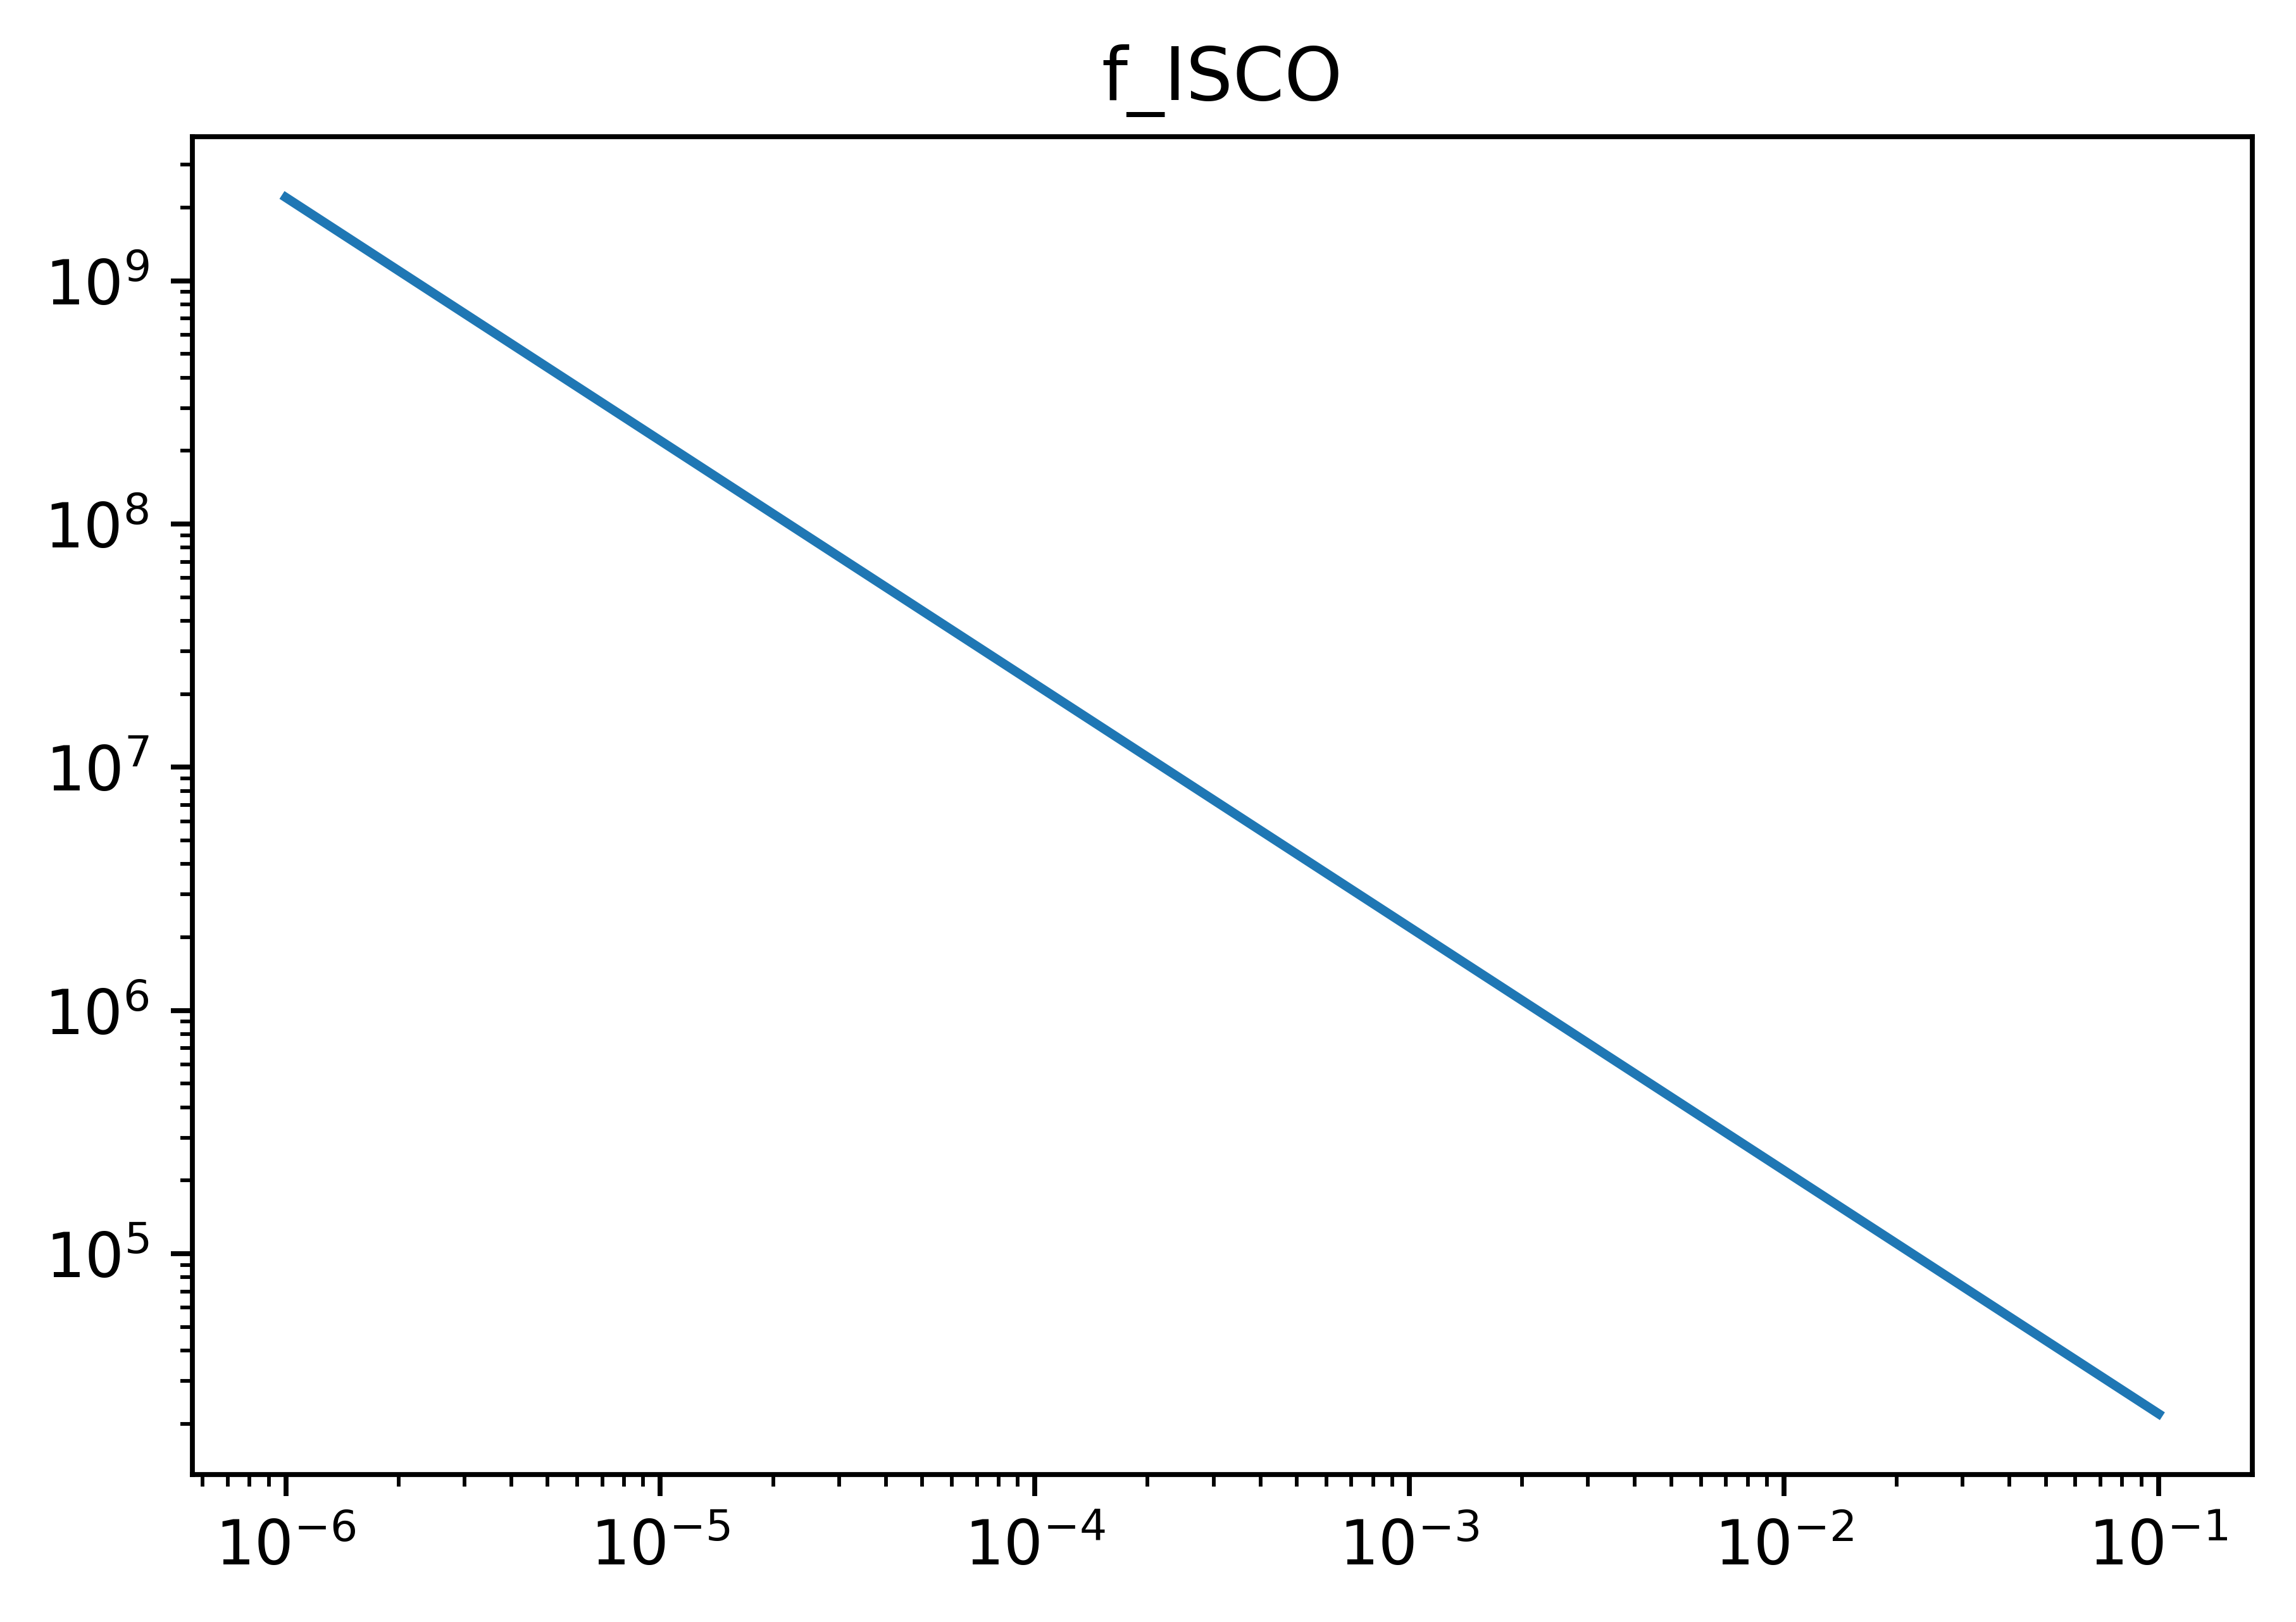

In [4]:
# Agrees with paper plot
pl.loglog(m_space, fISCO_arr)
pl.title("f_ISCO")

Text(0.5, 0, 'Total mass ($M_\\odot$)')

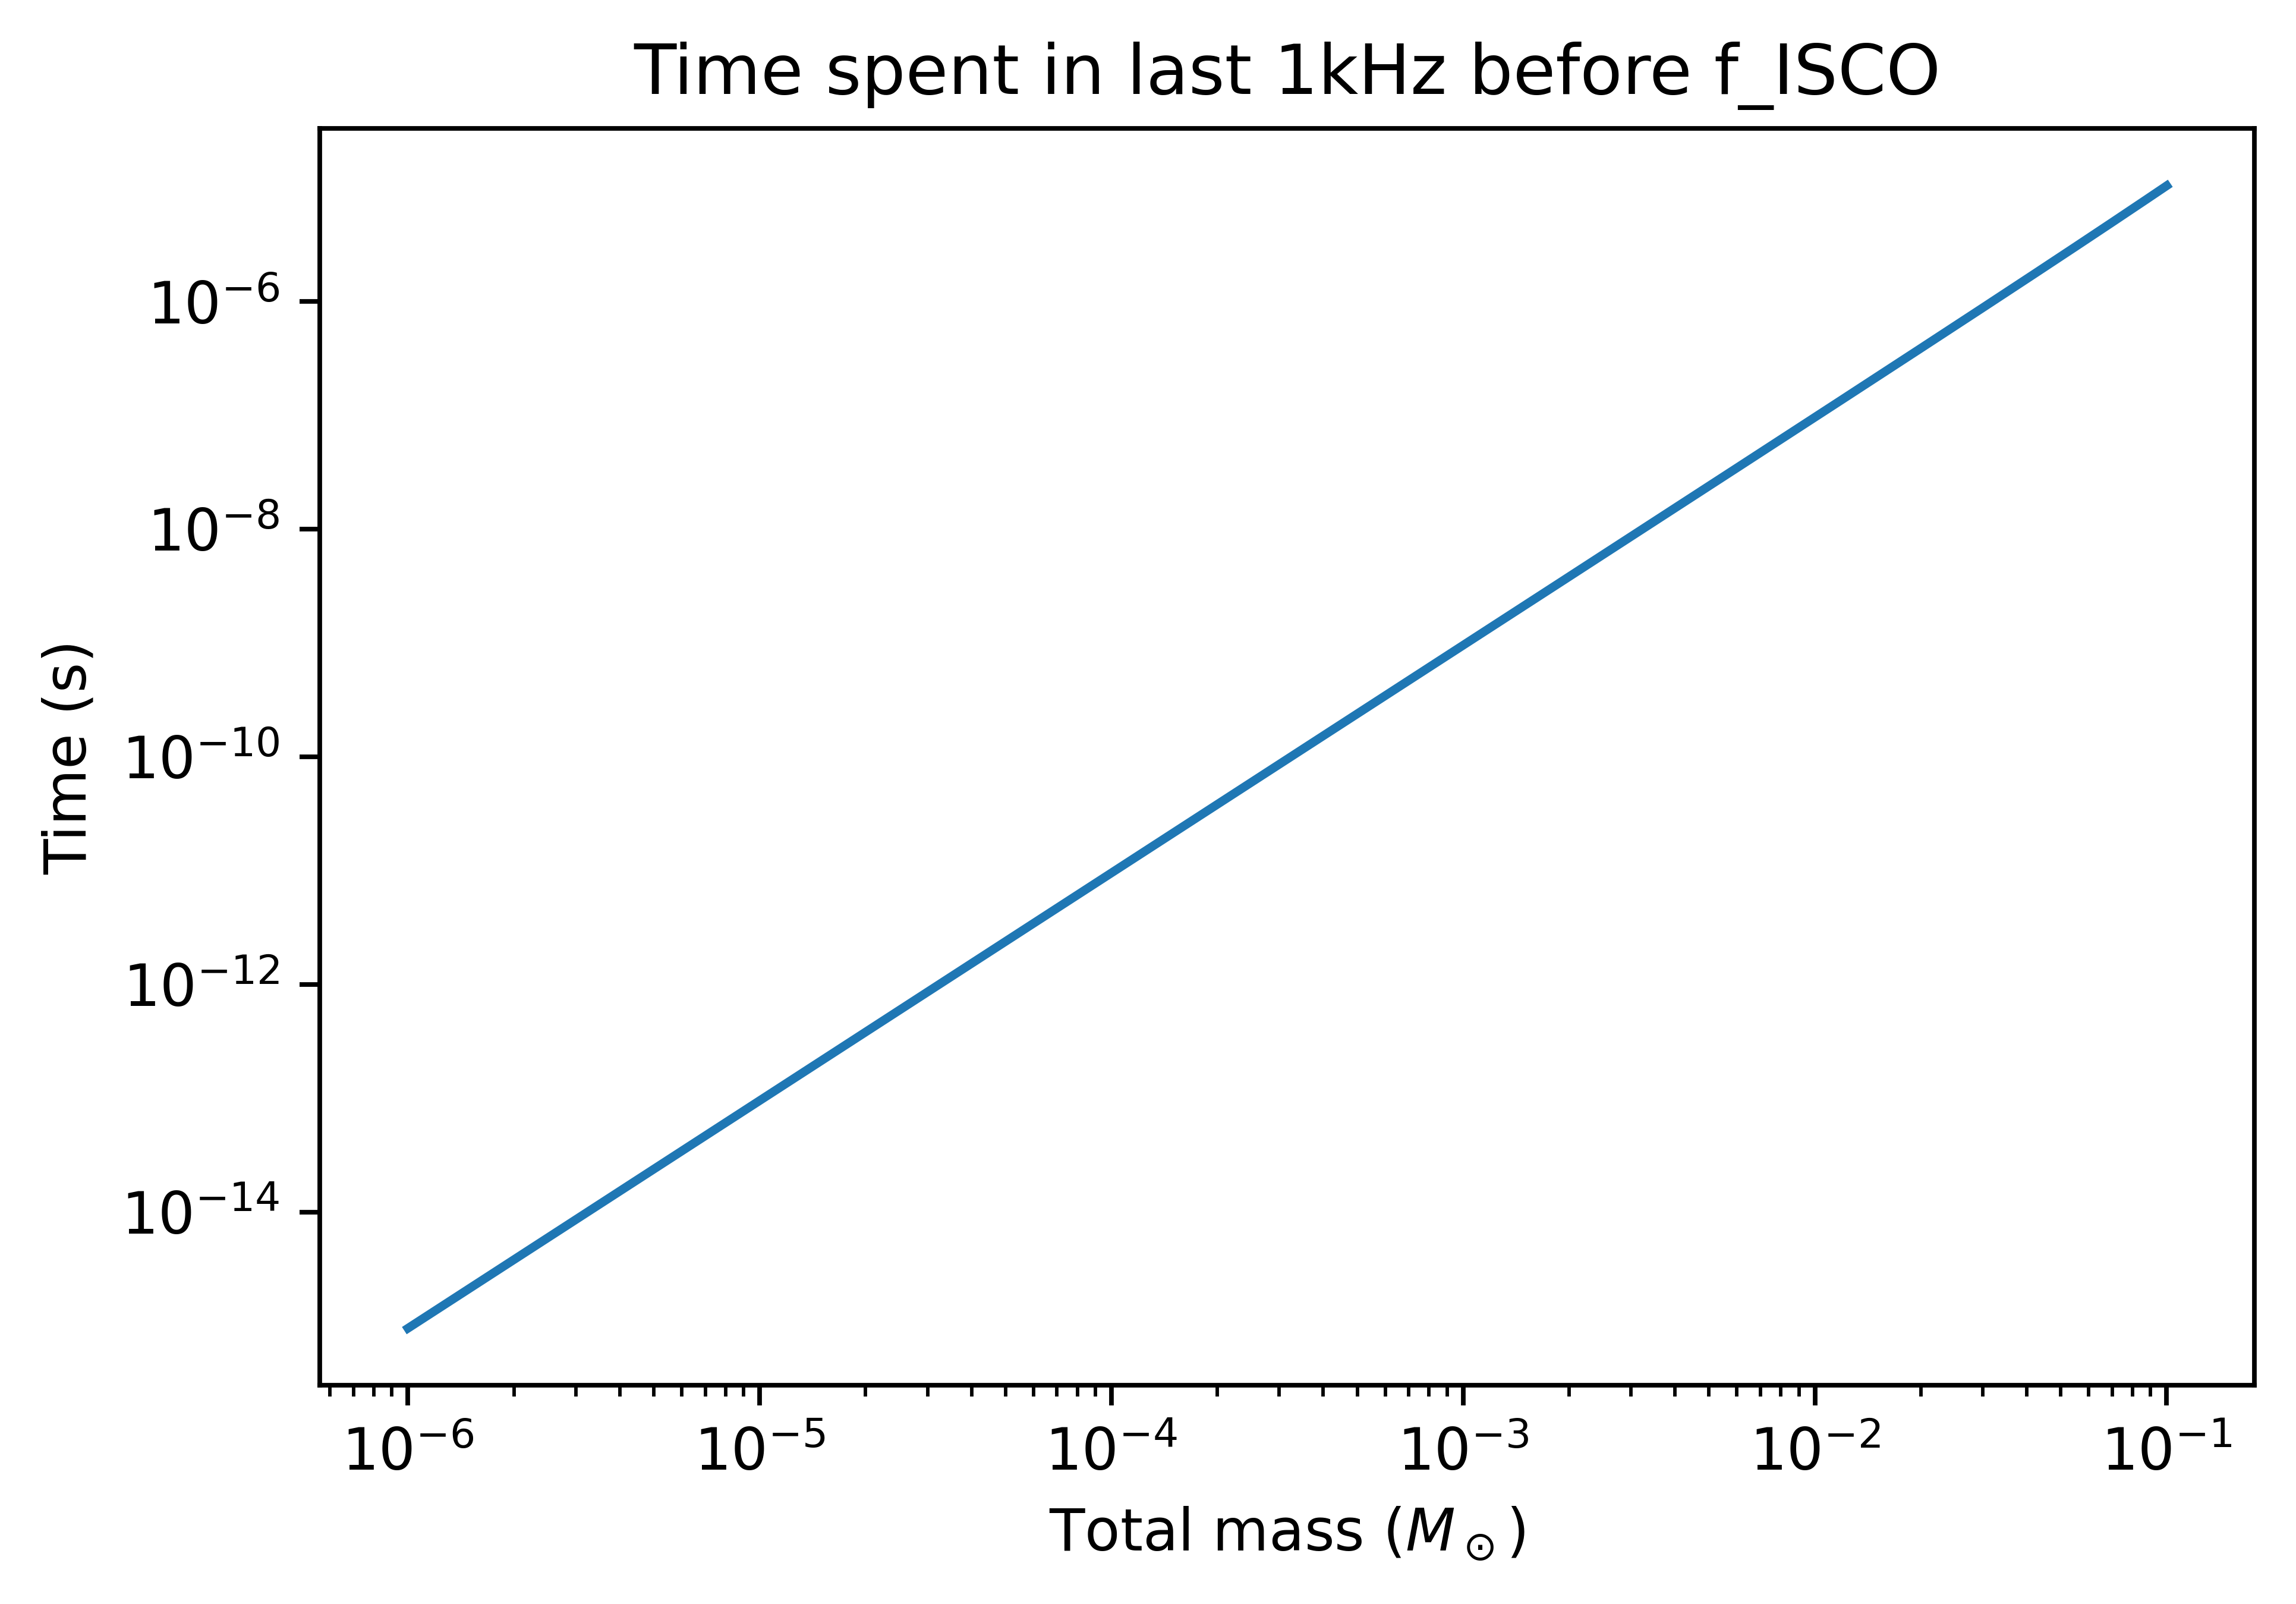

In [5]:
# Agrees with Cristiano, because the last 1kHz is smaller percentage
pl.loglog(m_space, time_arr)
pl.title("Time spent in last 1kHz before f_ISCO")
pl.ylabel('Time (s)')
pl.xlabel('Total mass ($M_\odot$)')

In [6]:
np.polyfit(np.log(m_space), np.log(time_arr), deg=1)

array([ 2.00318106, -6.92287123])

In [7]:
last_percent = []
for i in m_space:
    f_0 = 0.99*f_ISCO(i)
    f_max = f_ISCO(i)
    beta = beta_calc(f_0, i)
    fISCO_arr.append(f_max)
    last_percent.append(t_calc(f_0, beta, f_max))

Text(0.5, 0, 'Total mass ($M_\\odot$)')

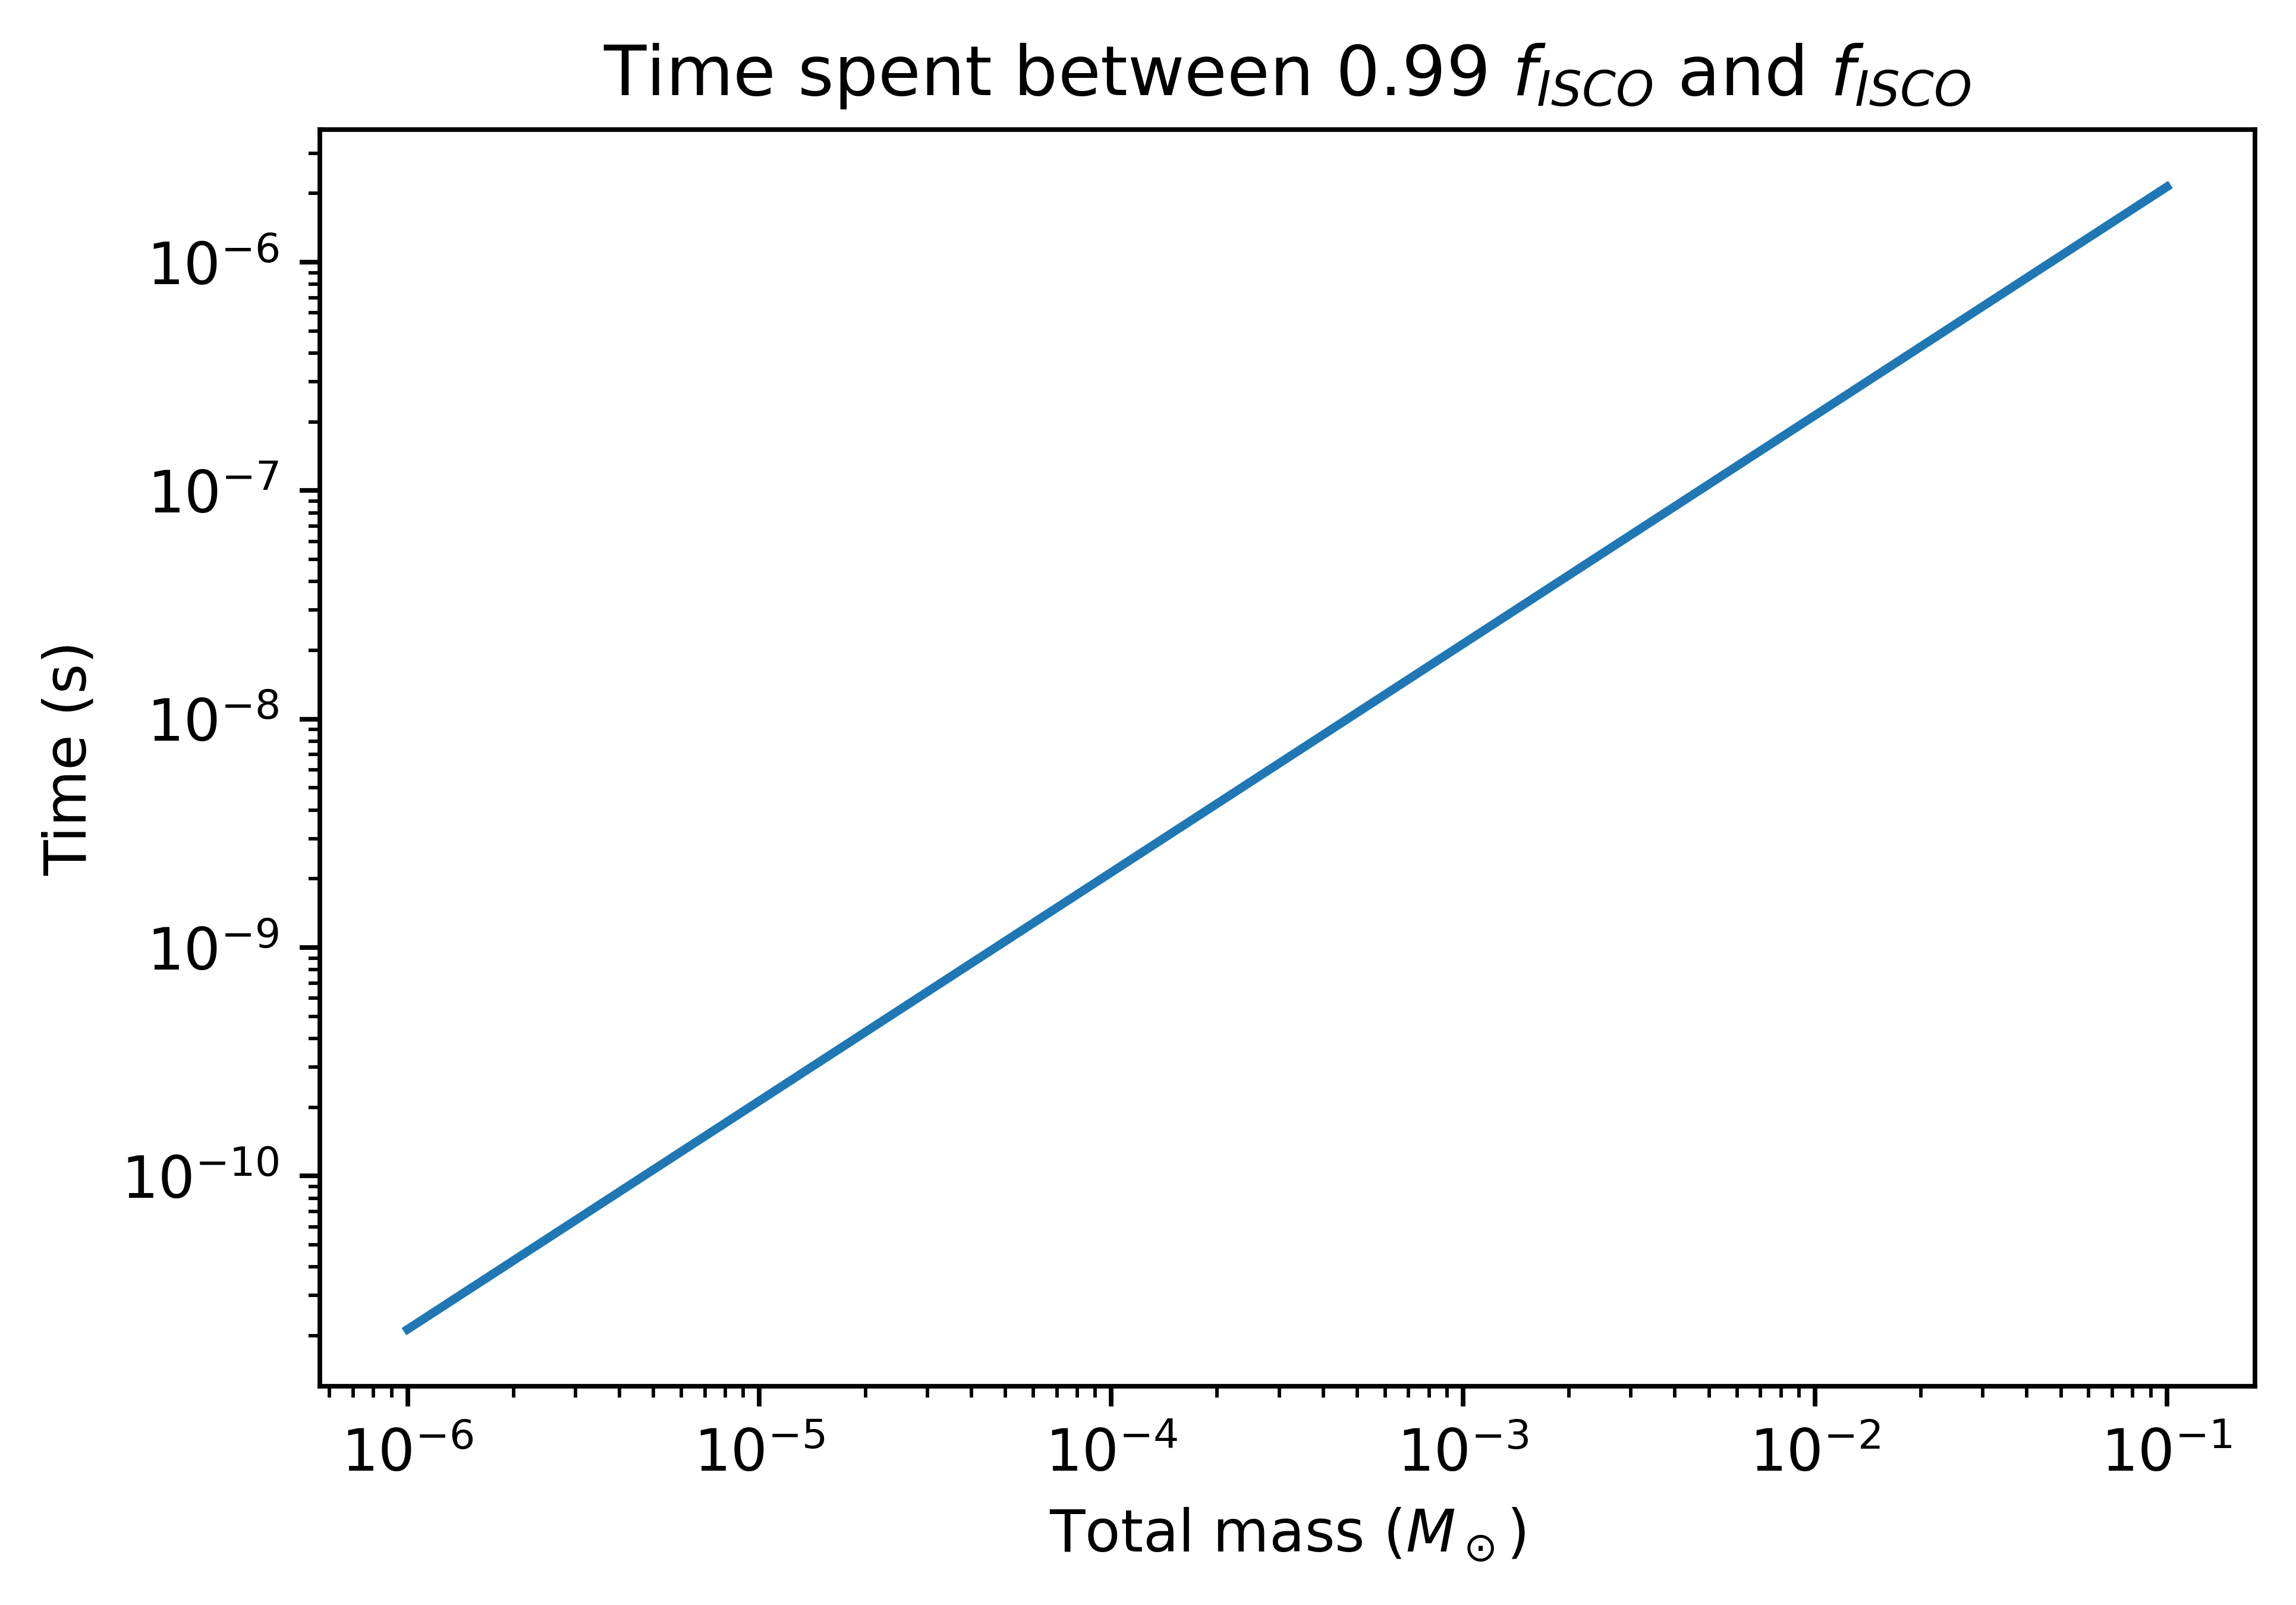

In [8]:
pl.loglog(m_space, last_percent)
pl.title("Time spent between 0.99 $f_{ISCO}$ and $f_{ISCO}$")
pl.ylabel('Time (s)')
pl.xlabel('Total mass ($M_\odot$)')

In [9]:
np.polyfit(np.log(m_space), np.log(last_percent), deg=1)

array([  1.        , -10.75415038])

In [10]:
# # If we fix the frequency band
# diffBand_arr0 = []
# diffBand_arr1 = []
# m_space = np.logspace(-6, -1, 1000)
# fmax_arr = [1e5, 1e6, 1e7]

# for j in fmax_arr:
#     fixedBand_time = []
#     for i in m_space:
#         f_max = j
#         f_0 = f_max - 1e3
#         beta = beta_calc(f_0, i)
#         if f_max < f_ISCO(i):
#             time = t_calc(f_0, beta, f_max)
#         else: 
#             time = np.nan
#         fixedBand_time.append(time)
#     diffBand_arr0.append(fixedBand_time)
    
# for j in fmax_arr:
#     fixedBand_time = []
#     for i in m_space:
#         f_max = j
#         f_0 = f_max - 1e0
#         beta = beta_calc(f_0, i)
#         if f_max < f_ISCO(i):
#             time = t_calc(f_0, beta, f_max)
#         else: 
#             time = np.nan
#         fixedBand_time.append(time)
#     diffBand_arr1.append(fixedBand_time)
    
# j=1e7
# largeBand_time = []
# for i in m_space:
#     f_max = j
#     f_0 = f_max - 1e6
#     beta = beta_calc(f_0, i)
#     if f_max < f_ISCO(i):
#         time = t_calc(f_0, beta, f_max)
#     else: 
#         time = np.nan
#     largeBand_time.append(time)
# largeBand_time = np.asarray(largeBand_time)

In [11]:
# label_arr0 = ['99kHz - 100KHz', '999KHz - 1MHz', '9.999MHz - 10MHz']
# label_arr1 = ['90kHz - 100KHz', '990KHz - 1MHz', '9.990MHz - 10MHz']
# col_arr = ['tab:blue', 'tab:orange', 'tab:green']
# for i, val in enumerate(diffBand_arr0):
#     pl.loglog(m_space, val, label = label_arr0[i], c=col_arr[i])
# for i, val in enumerate(diffBand_arr1):
#     pl.loglog(m_space, val, label = label_arr1[i], ls = '--', c=col_arr[i])
# pl.loglog(m_space, largeBand_time, label = '9MHz - 10MHz', markevery=np.arange(s0, len(m_space), 50), \
#           marker = 'x', ls = '--', c='tab:green')
# # pl.loglog(m_space, np.divide(1, fISCO_arr), ls='dashdot')
# pl.title("Signal duration inside different detector bands")
# pl.ylabel('Time (s)')
# pl.xlabel('Total mass ($M_\odot$)')
# pl.legend(ncol=3, fontsize = 'xx-small')
# pl.xlim(6e-7, 6e-2)
# pl.ylim(1e-14, 1e2)

In [12]:
# If we fix the frequency band
diffBand_arr0 = []
diffBand_arr1 = []
m_space = np.logspace(-6, -1, 1000)
fmax_arr = [1e5, 1e6, 1e7]

for j in fmax_arr:
    fixedBand_time = []
    for i in m_space:
        f_max = j
        f_0 = f_max - 1e3
        beta = beta_calc(f_0, i)
        if f_max < f_ISCO(i):
            time = t_calc(f_0, beta, f_max)
        else: 
            time = np.nan
        fixedBand_time.append(time)
    diffBand_arr0.append(fixedBand_time)
    
for j in fmax_arr:
    fixedBand_time = []
    for i in m_space:
        f_max = j
        f_0 = f_max - 1e2
        beta = beta_calc(f_0, i)
        if f_max < f_ISCO(i):
            time = t_calc(f_0, beta, f_max)
        else: 
            time = np.nan
        fixedBand_time.append(time)
    diffBand_arr1.append(fixedBand_time)

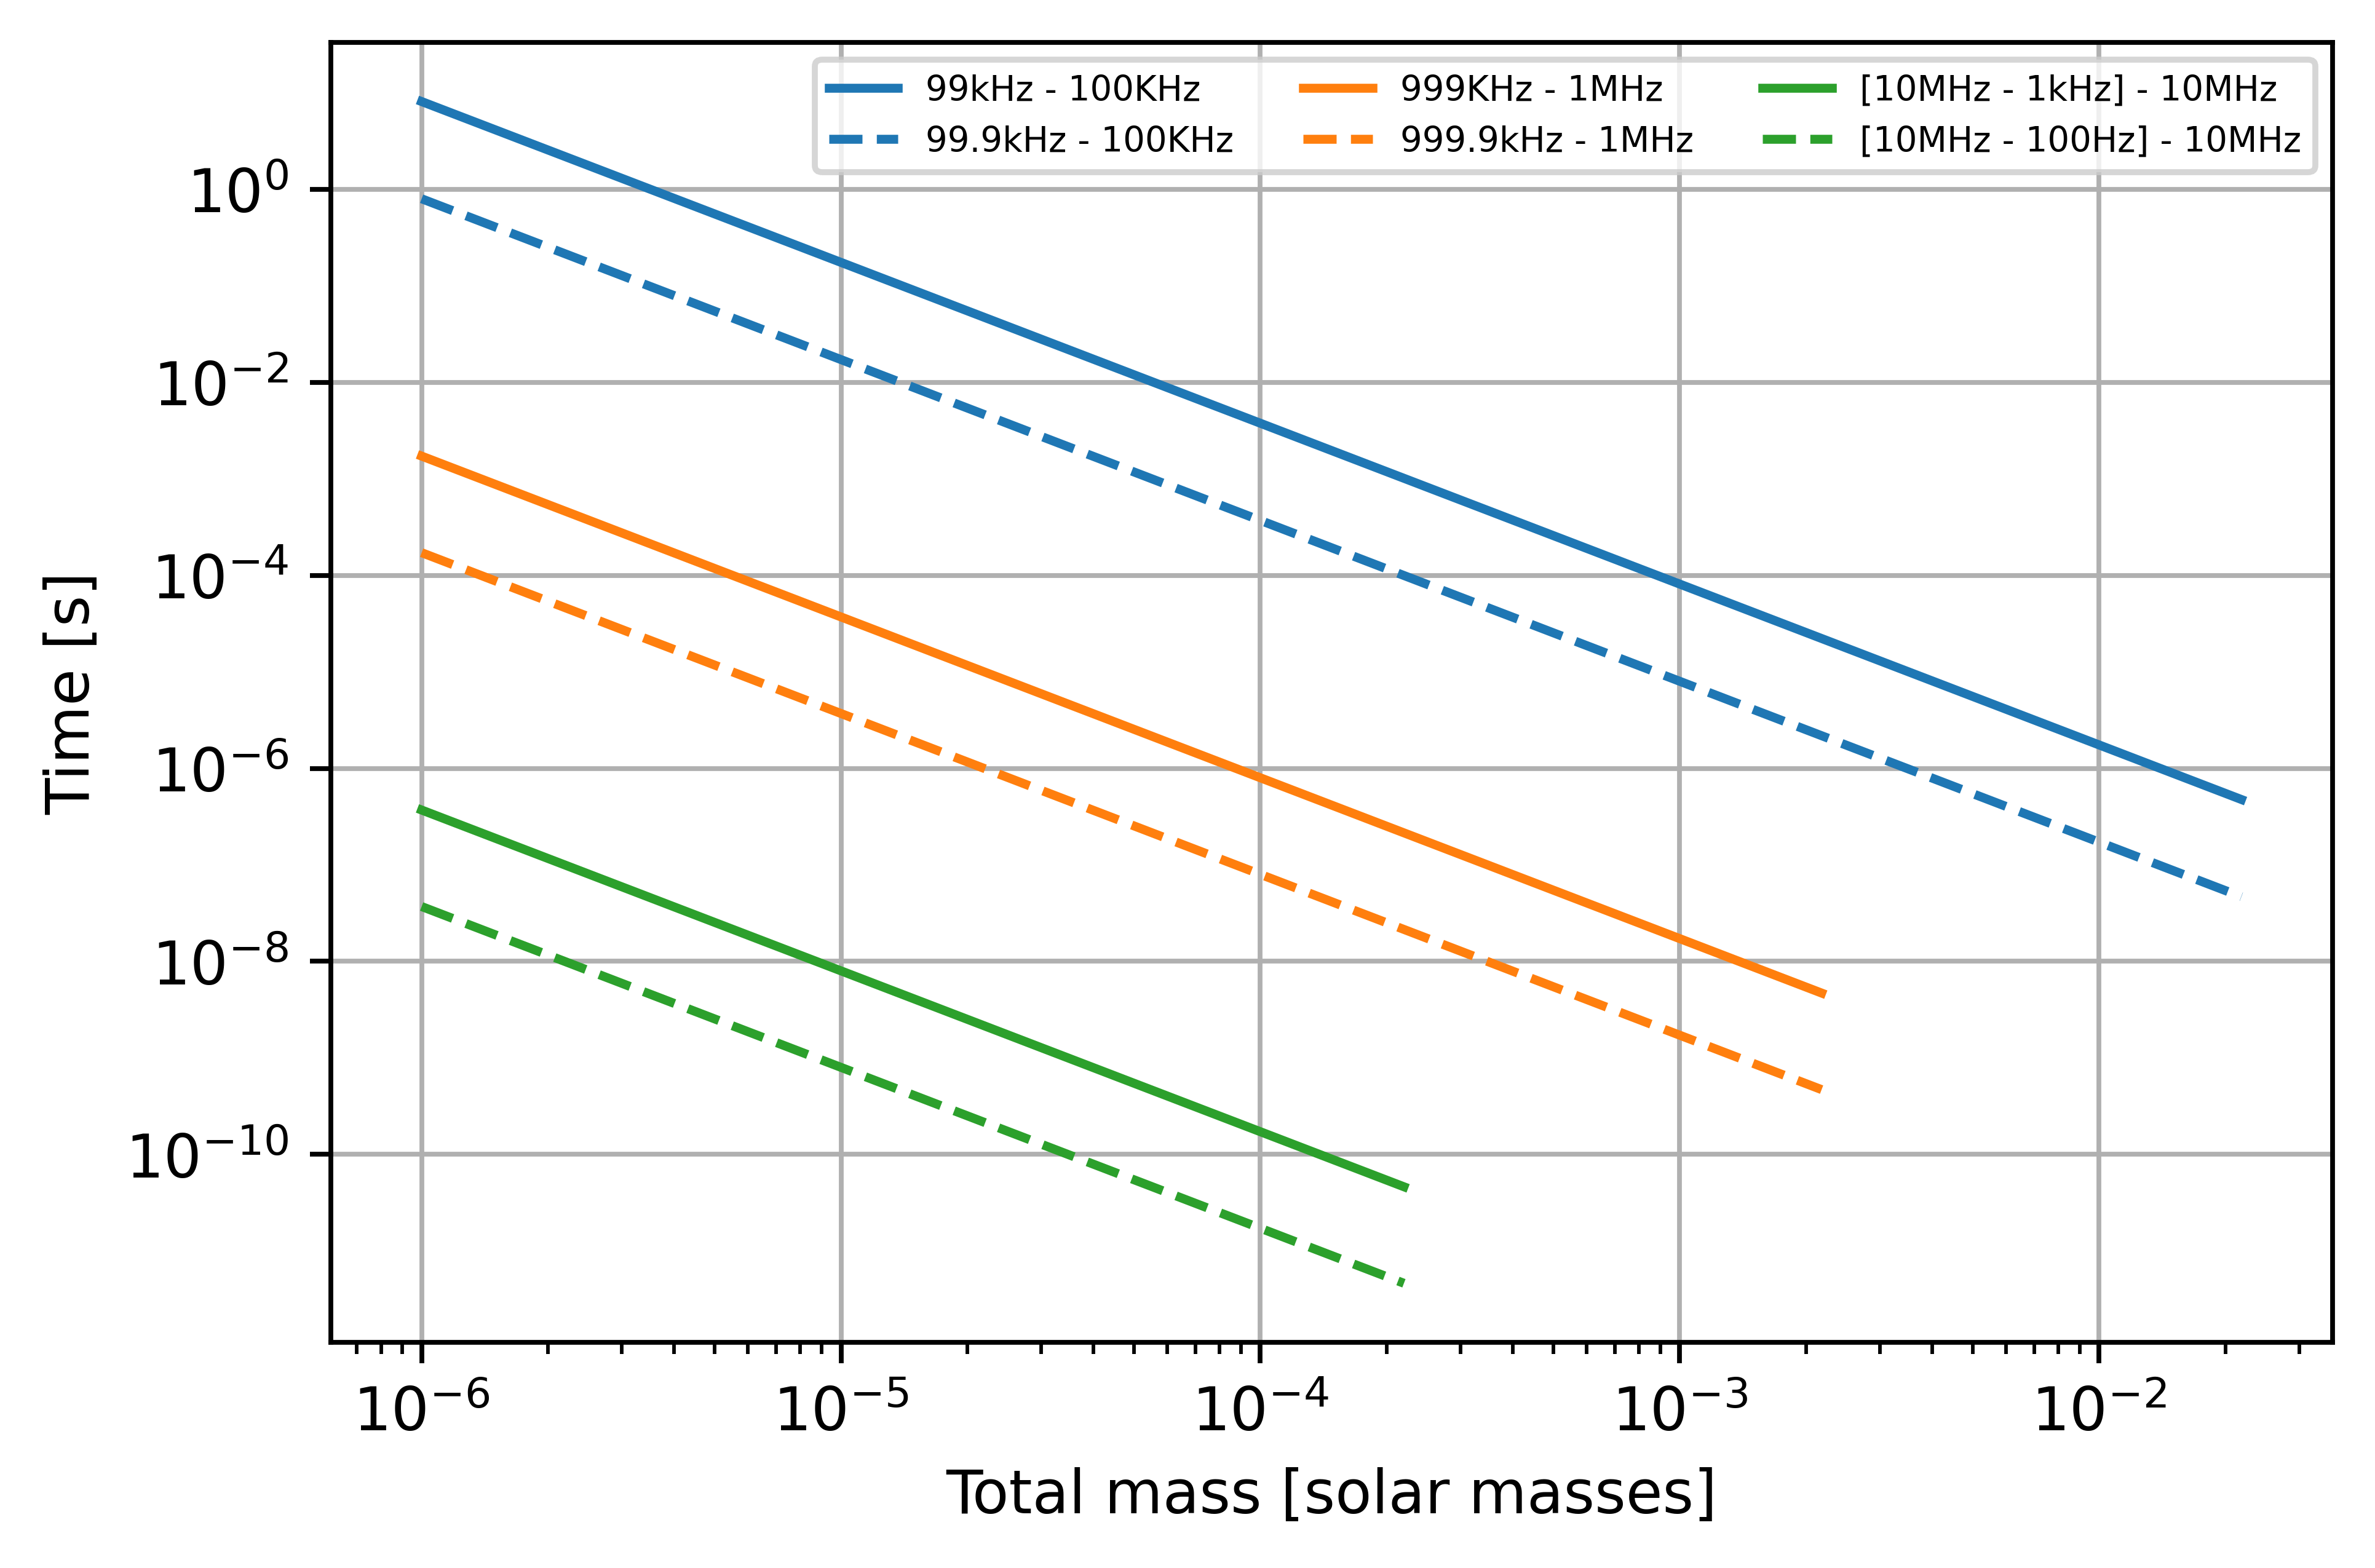

In [17]:
label_arr0 = ['99kHz - 100KHz', '999KHz - 1MHz', '[10MHz - 1kHz] - 10MHz']
label_arr1 = ['99.9kHz - 100KHz', '999.9kHz - 1MHz', '[10MHz - 100Hz] - 10MHz']
col_arr = ['tab:blue', 'tab:orange', 'tab:green']
for i, val in enumerate(diffBand_arr0):
    pl.loglog(m_space, val, label = label_arr0[i], c=col_arr[i])
    pl.loglog(m_space, diffBand_arr1[i], label = label_arr1[i], ls = '--', c=col_arr[i])
# pl.loglog(m_space, np.divide(1, fISCO_arr), ls='dashdot')
# pl.title("Signal duration inside different detector bands")
pl.ylabel('Time [s]')
pl.xlabel('Total mass [solar masses]')
pl.legend(ncol=3, fontsize = 'xx-small')
pl.grid(True)
# pl.xlim(6e-7, 6e-2)
# pl.ylim(1e-14, 1e2)

In [14]:
# label_arr = ['99kHz - 100KHz', '999KHz - 1MHz', '9.999MHz - 10MHz']
pl.loglog(m_space, fixedBand_time0)
pl.loglog(m_space, fixedBand_time1)
pl.title("Signal duration inside different detector bands")
pl.ylabel('Time (s)')
pl.xlabel('Total mass ($M_\odot$)')
pl.legend()

NameError: name 'fixedBand_time0' is not defined

In [ ]:
test = np.array([2,4,6,3,1,4])
idx = np.argsort(test)
thresh_idx = np.searchsorted(test, 2, sorter=idx)
test[idx][thresh_idx:]